In [36]:
import numpy as np
import jax.numpy as jnp
from dyn_modelling.models.cell_lattice import build_lattice, simulate_cell_lattice, compute_distance_matrix, compute_weights, compute_rhs, external_signal
from dyn_modelling.methods.neuralODE import init_vf_params, make_neural_ode, train_adam,train_SGD, solve_node,vf_forward
from dyn_modelling.utils.plots import plot_graph, plot_trajectories, plot_loss, plot_parameter_evolution, plot_predictions, plot_phase_portrait


# 30 cells

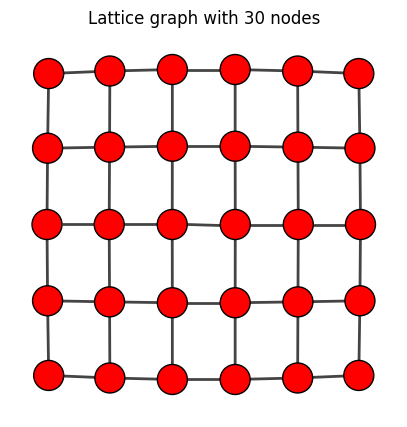

In [37]:
rows, cols = 5, 6
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

## 2. Simulate cell lattice - single trajectory 

In [38]:
# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 10.0, 100.0
t_end, n_steps = 100.0, 100
neigh_order = 2

# Build RHS
dist_matrix = compute_distance_matrix(g)
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)


# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)

# Simulate
y = simulate_cell_lattice(rhs, x0, (0, t_end), t_eval)

## 3. Plot trajectories — clean data


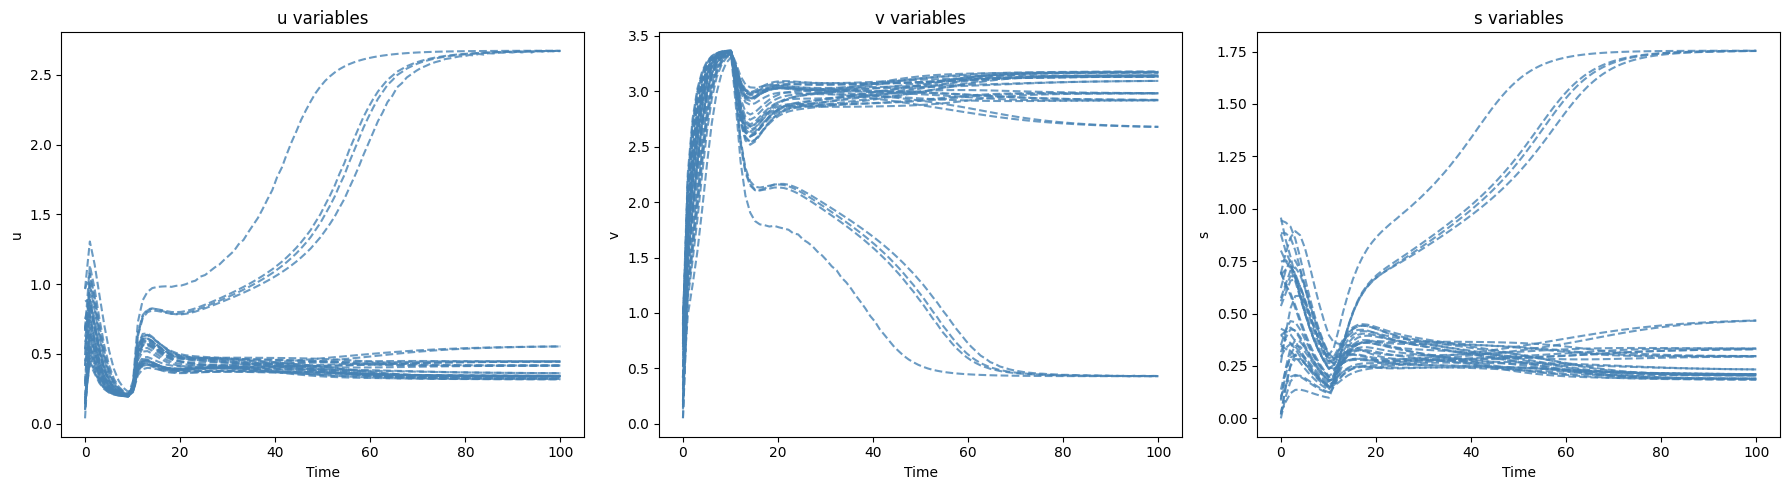

In [40]:
plot_trajectories(t_eval, y)

## 4. Plot trajectories — noisy data


In [41]:
#y_noisy = add_noise(y, noise_level=0.1)
#plot_trajectories(t_eval, y_noisy)

## 5. NeuralODE

In [42]:
ts = jnp.array(t_eval)       # (n_steps,)
y0 = jnp.array(y[:, 0])      # initial condition (3*N,)
y_true = jnp.array(y.T)      # (n_steps, 3*N)


np.random.seed(42)
vf_params = init_vf_params(data_size=3*N, width=64, depth=3)
loss_fn, grad_fn = make_neural_ode()

vf_params, loss_history = train_adam(
    vf_params, y0, ts, y_true,
    loss_fn, grad_fn,
    n_epochs=20_000, lr=1e-3
)

[     0] loss = 1.906960
[  2000] loss = 0.001957
[  4000] loss = 0.000800
[  6000] loss = 0.000504
[  8000] loss = 0.000449
[ 10000] loss = 0.000189
[ 12000] loss = 0.000153
[ 14000] loss = 0.000197
[ 16000] loss = 0.000109
[ 18000] loss = 0.000079


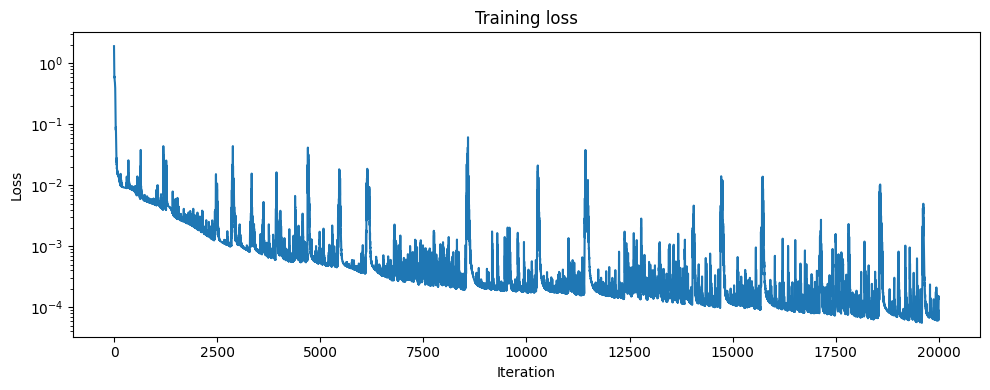

In [43]:
plot_loss(loss_history)

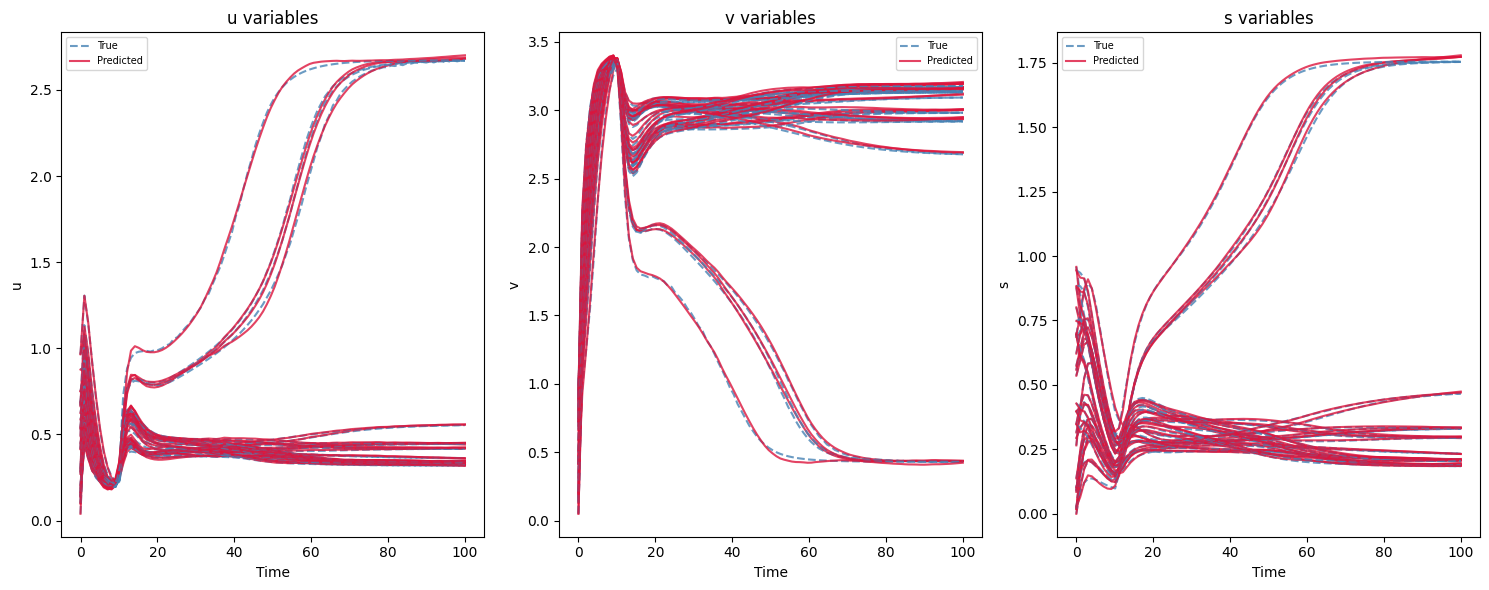

In [44]:

y_pred = np.array(solve_node(vf_params, y0, ts))  # (n_steps, 3*N)

plot_predictions(t_eval, y_pred, y_true, figsize=(15, 6))


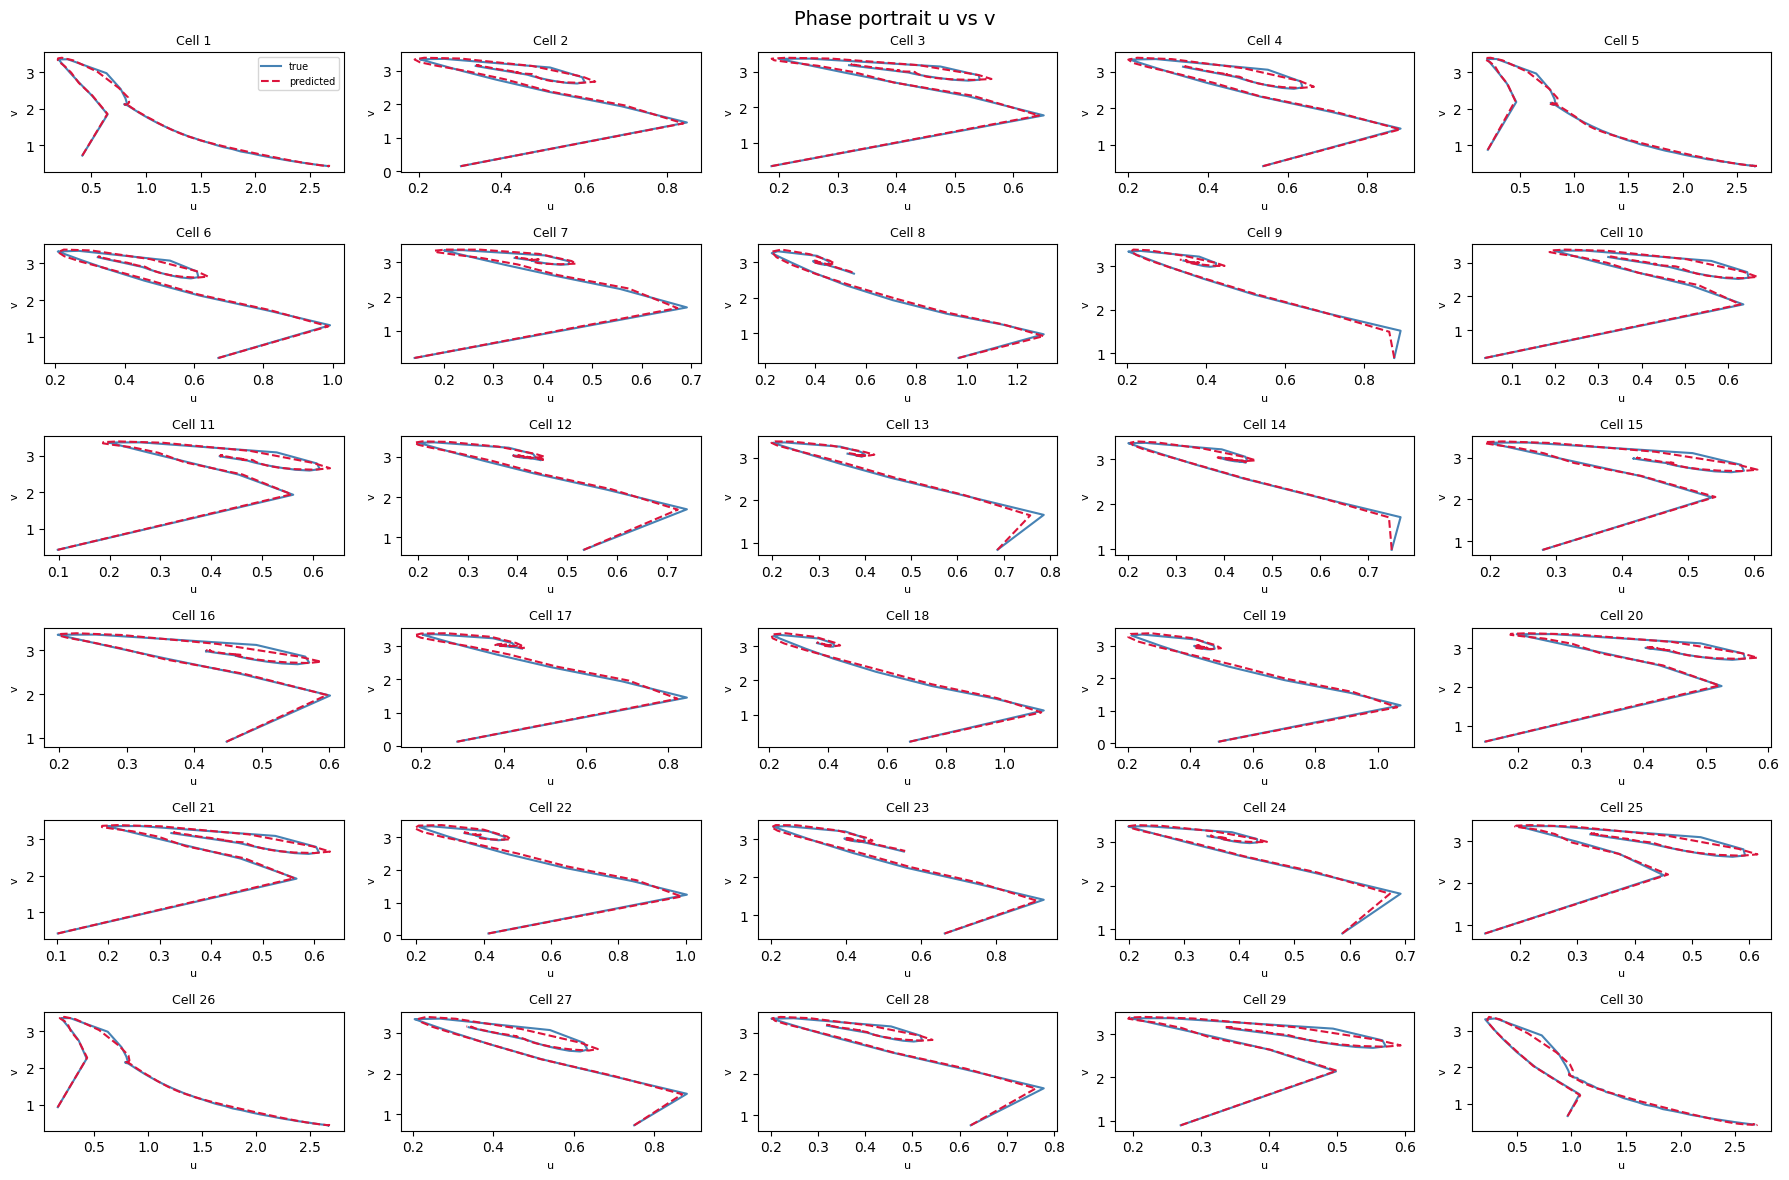

In [45]:
# phase portrait 
plot_phase_portrait(y_true, y_pred, n_cells=30)

In [46]:
def compute_prediction_error(vf_params, y0, ts, y_true):
    y_pred = solve_node(vf_params, y0, ts)
    rel_l2 = jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true)
    return float(rel_l2)

In [47]:
rel_l2 = compute_prediction_error(vf_params, y0, ts, y_true)
print(f"Relative L2 error: {rel_l2:.4f}")

Relative L2 error: 0.0068


In [ ]:
import numpy as np
import jax.numpy as jnp
from scipy.stats import spearmanr, kruskal, ks_2samp
from dyn_modelling.methods.SINDy import split_uvs, compute_phi
from dyn_modelling.models.cell_lattice import compute_weights


def compute_prediction_error_breakdown(vf_params, y0, ts, y_true, N):
    """
    Relative L2 error per variable (u, v, s) and per cell.   
    """
    y_pred = solve_node(vf_params, y0, ts)  # (len(ts), 3*N)

    var_names = ['u', 'v', 's']
    per_var = {}
    for i, name in enumerate(var_names):
        idx = jnp.arange(i, 3 * N, 3)
        pred_slice = y_pred[:, idx]
        true_slice = y_true[:, idx]
        rel_l2 = jnp.linalg.norm(pred_slice - true_slice) / jnp.linalg.norm(true_slice)
        per_var[name] = float(rel_l2)

    per_cell = jnp.zeros(N)
    for cell in range(N):
        idx = jnp.array([3 * cell, 3 * cell + 1, 3 * cell + 2])
        pred_cell = y_pred[:, idx]
        true_cell = y_true[:, idx]
        rel_l2_cell = jnp.linalg.norm(pred_cell - true_cell) / jnp.linalg.norm(true_cell)
        per_cell = per_cell.at[cell].set(rel_l2_cell)

    return per_var, per_cell


def classify_cells(rows, cols):
    """Corner / edge (border, non-corner) / interior indices, row-major."""
    corner_idx, edge_idx, interior_idx = [], [], []
    for idx in range(rows * cols):
        r, c = idx // cols, idx % cols
        n_boundaries = sum([r == 0, r == rows - 1, c == 0, c == cols - 1])
        if n_boundaries >= 2:
            corner_idx.append(idx)
        elif n_boundaries == 1:
            edge_idx.append(idx)
        else:
            interior_idx.append(idx)
    return (np.array(corner_idx), np.array(edge_idx), np.array(interior_idx))


def run_boundary_tests(rows, cols, dist_matrix, neigh_order, y, per_cell_rel_err, label=""):
    N = rows * cols
    w = np.array(compute_weights(dist_matrix, neigh_order))
    degree = (w > 0).sum(axis=1)

    corner_idx, edge_idx, interior_idx = classify_cells(rows, cols)
    err = np.array(per_cell_rel_err)

    # Test Spearman, node degree vs per-cell error
    rho, pval_a = spearmanr(degree, err)

    # `Test Kruskal-Wallis, corner vs edge vs interior`
    stat_b, pval_b = kruskal(err[corner_idx], err[edge_idx], err[interior_idx])

    # Test Kolmogorov-Smirnov, boundary vs interior
    u, v, s = split_uvs(np.array(y))       # y: (3N, n_steps) -> u,v,s: (n_steps, N)
    Phi = compute_phi(s, w)                # (n_steps, N)

    boundary_idx = np.concatenate([corner_idx, edge_idx])
    stat_c, pval_c = ks_2samp(Phi[:, boundary_idx].ravel(), Phi[:, interior_idx].ravel())

    print(f"{label}")
    print(f"Spearman rho={rho:.3f}  p={pval_a:.4g}")
    print(f"Kruskal H={stat_b:.3f}  p={pval_b:.4g}")
    print(f"KS D={stat_c:.3f}  p={pval_c:.4g}")
    print()

    return dict(label=label, rho=rho, pval_a=pval_a, H=stat_b, pval_b=pval_b, D=stat_c, pval_c=pval_c)

In [68]:
per_var, per_cell = compute_prediction_error_breakdown(vf_params, y0, ts, y_true, N)

print("Per-variable relative L2:")
for name, err in per_var.items():
    print(f"  {name}: {err:.4f}")

print(f"\nPer-cell relative L2: min={per_cell.min():.4f}, max={per_cell.max():.4f}, mean={per_cell.mean():.4f}")

worst_cells = jnp.argsort(per_cell)[::-1][:5]
print(f"Worst 5 cells (indices): {worst_cells}")

res_30 = run_boundary_tests(rows, cols, dist_matrix, neigh_order, y, per_cell, label="Neural ODE — 30 cells")

Per-variable relative L2:
  u: 0.0477
  v: 0.0110
  s: 0.0557

Per-cell relative L2: min=0.0087, max=0.0410, mean=0.0153
Worst 5 cells (indices): [ 0 99 90  9 98]
=== Neural ODE — 30 cells ===
  Test A  Spearman rho=-0.509  p=6.515e-08
  Test B  Kruskal H=36.706  p=1.07e-08
  Test C  KS D=0.559  p=2.278e-321



# 100 cells

## 1. Build the lattice


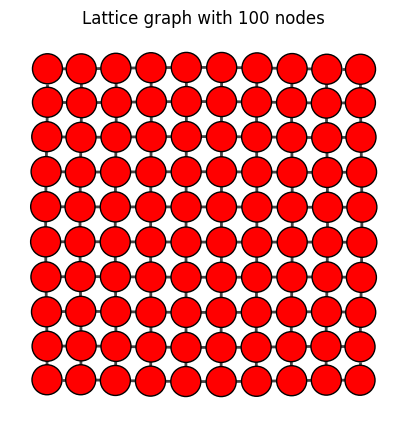

In [52]:
rows, cols = 10, 10
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

## 2. Simulate cell lattice - single trajectory 

In [53]:
# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 10.0, 100.0
t_end, n_steps = 100.0, 100
neigh_order = 2

# Build RHS
dist_matrix = compute_distance_matrix(g)
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)


# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)

# Simulate
y = simulate_cell_lattice(rhs, x0, (0, t_end), t_eval)

## 3. Plot trajectories — clean data


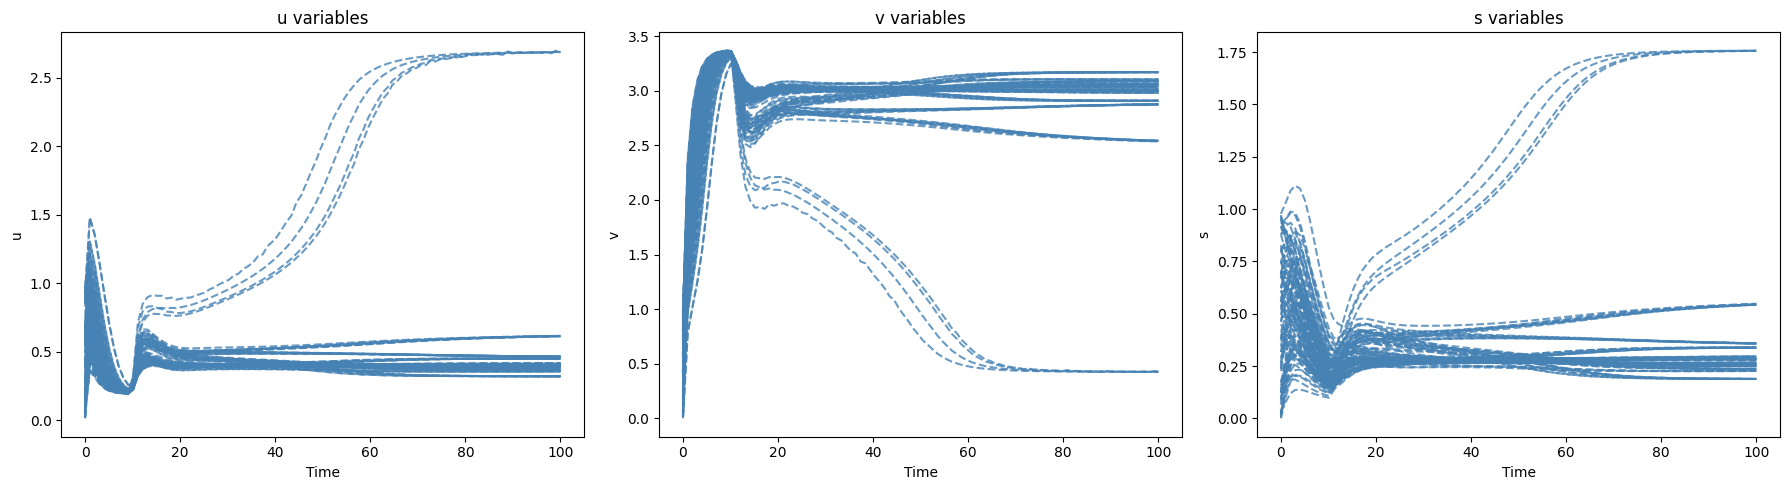

In [54]:
plot_trajectories(t_eval, y)

## 4. Plot trajectories — noisy data


In [55]:
#y_noisy = add_noise(y, noise_level=0.1)
#plot_trajectories(t_eval, y_noisy)

## 5. NeuralODE

In [56]:
ts = jnp.array(t_eval)       # (n_steps,)
y0 = jnp.array(y[:, 0])      # initial condition (3*N,)
y_true = jnp.array(y.T)      # (n_steps, 3*N)


np.random.seed(42)
vf_params = init_vf_params(data_size=3*N, width=64, depth=3)
loss_fn, grad_fn = make_neural_ode()

vf_params, loss_history = train_adam(
    vf_params, y0, ts, y_true,
    loss_fn, grad_fn,
    n_epochs=20_000, lr=1e-3
)

[     0] loss = 1.901299
[  2000] loss = 0.001636
[  4000] loss = 0.024056
[  6000] loss = 0.000439
[  8000] loss = 0.000482
[ 10000] loss = 0.000423
[ 12000] loss = 0.000272
[ 14000] loss = 0.001596
[ 16000] loss = 0.000373
[ 18000] loss = 0.000128


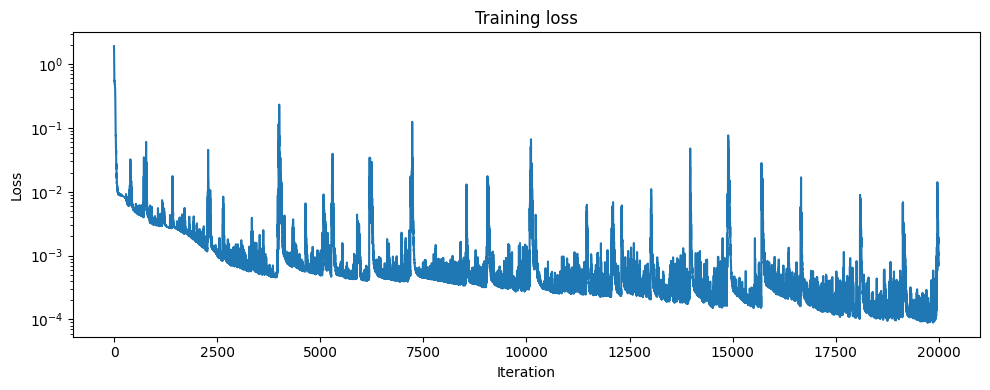

In [57]:
plot_loss(loss_history)

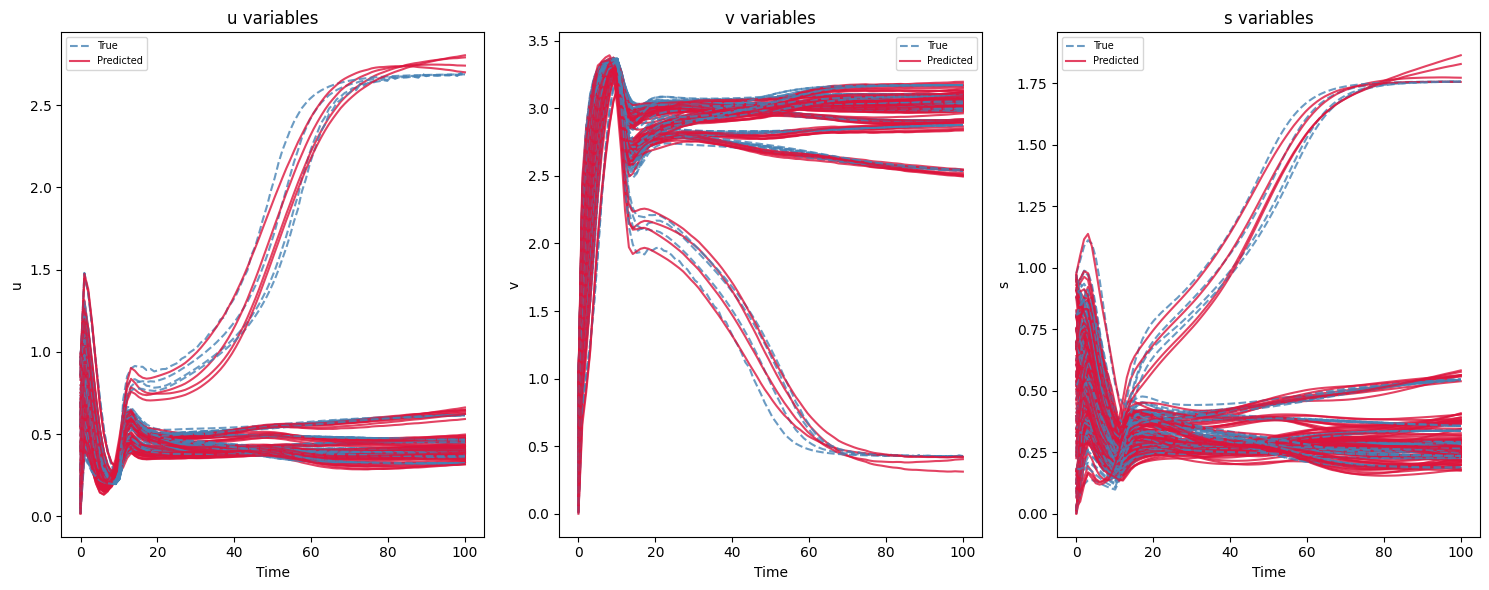

In [58]:

y_pred = np.array(solve_node(vf_params, y0, ts))  # (n_steps, 3*N)

plot_predictions(t_eval, y_pred, y_true, figsize=(15, 6))


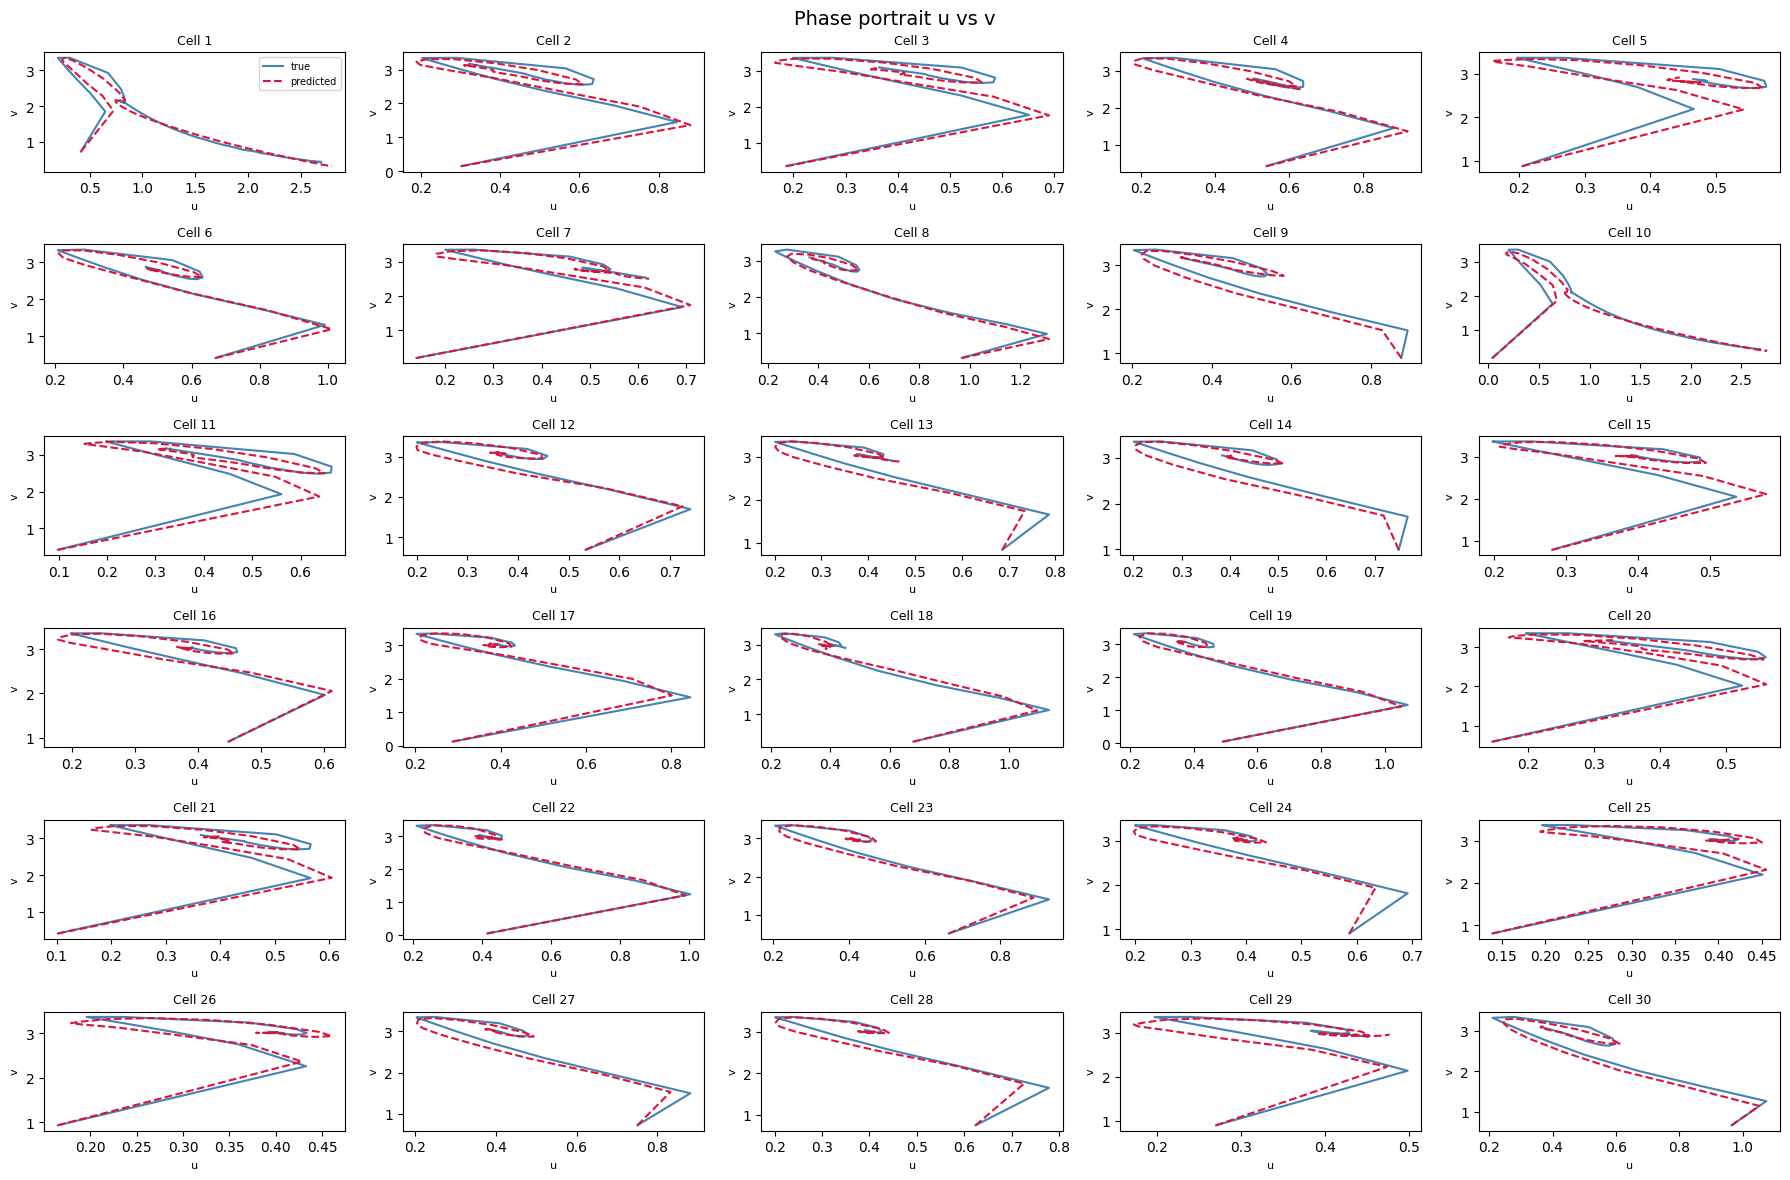

In [59]:
# phase portrait 
plot_phase_portrait(y_true, y_pred, n_cells=30)

In [60]:
def compute_prediction_error(vf_params, y0, ts, y_true):
    y_pred = solve_node(vf_params, y0, ts)
    rel_l2 = jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true)
    return float(rel_l2)

In [61]:
rel_l2 = compute_prediction_error(vf_params, y0, ts, y_true)
print(f"Relative L2 error: {rel_l2:.4f}")

Relative L2 error: 0.0160


In [64]:

def compute_prediction_error_breakdown(vf_params, y0, ts, y_true, N):
    """
    Relative L2 error breakdown per variable (u, v, s) and per cell.

    State layout: blocked-by-cell [u0,v0,s0, u1,v1,s1, ...]
    (confirmed against SINDy.split_uvs — NOT blocked-by-variable).
    """
    y_pred = solve_node(vf_params, y0, ts)  # (len(ts), 3*N)

    var_names = ['u', 'v', 's']
    per_var = {}
    for i, name in enumerate(var_names):
        idx = jnp.arange(i, 3 * N, 3)
        pred_slice = y_pred[:, idx]
        true_slice = y_true[:, idx]
        rel_l2 = jnp.linalg.norm(pred_slice - true_slice) / jnp.linalg.norm(true_slice)
        per_var[name] = float(rel_l2)

    per_cell = jnp.zeros(N)
    for cell in range(N):
        idx = jnp.array([3 * cell, 3 * cell + 1, 3 * cell + 2])
        pred_cell = y_pred[:, idx]
        true_cell = y_true[:, idx]
        rel_l2_cell = jnp.linalg.norm(pred_cell - true_cell) / jnp.linalg.norm(true_cell)
        per_cell = per_cell.at[cell].set(rel_l2_cell)

    return per_var, per_cell


def classify_cells(rows, cols):
    """Corner / edge (border, non-corner) / interior indices, row-major."""
    corner_idx, edge_idx, interior_idx = [], [], []
    for idx in range(rows * cols):
        r, c = idx // cols, idx % cols
        n_boundaries = sum([r == 0, r == rows - 1, c == 0, c == cols - 1])
        if n_boundaries >= 2:
            corner_idx.append(idx)
        elif n_boundaries == 1:
            edge_idx.append(idx)
        else:
            interior_idx.append(idx)
    return (np.array(corner_idx), np.array(edge_idx), np.array(interior_idx))


def run_boundary_tests(rows, cols, dist_matrix, neigh_order, y, per_cell_rel_err, label=""):
    N = rows * cols
    w = np.array(compute_weights(dist_matrix, neigh_order))
    degree = (w > 0).sum(axis=1)

    corner_idx, edge_idx, interior_idx = classify_cells(rows, cols)
    err = np.array(per_cell_rel_err)

    # Test A: Spearman, grado del nodo vs errore per-cella
    rho, pval_a = spearmanr(degree, err)

    # Test B: Kruskal-Wallis, angolo vs bordo vs interno
    stat_b, pval_b = kruskal(err[corner_idx], err[edge_idx], err[interior_idx])

    # Test C: KS su Phi(t), bordo (angolo+edge) vs interno
    u, v, s = split_uvs(np.array(y))       # y: (3N, n_steps) -> u,v,s: (n_steps, N)
    Phi = compute_phi(s, w)                # (n_steps, N)

    boundary_idx = np.concatenate([corner_idx, edge_idx])
    stat_c, pval_c = ks_2samp(Phi[:, boundary_idx].ravel(), Phi[:, interior_idx].ravel())

    print(f"=== {label} ===")
    print(f"  Test A  Spearman rho={rho:.3f}  p={pval_a:.4g}")
    print(f"  Test B  Kruskal H={stat_b:.3f}  p={pval_b:.4g}")
    print(f"  Test C  KS D={stat_c:.3f}  p={pval_c:.4g}")
    print()

    return dict(label=label, rho=rho, pval_a=pval_a, H=stat_b, pval_b=pval_b, D=stat_c, pval_c=pval_c)

In [65]:
per_var, per_cell = compute_prediction_error_breakdown(vf_params, y0, ts, y_true, N)

print("Per-variable relative L2:")
for name, err in per_var.items():
    print(f"  {name}: {err:.4f}")

print(f"\nPer-cell relative L2: min={per_cell.min():.4f}, max={per_cell.max():.4f}, mean={per_cell.mean():.4f}")

worst_cells = jnp.argsort(per_cell)[::-1][:5]
print(f"Worst 5 cells (indices): {worst_cells}")

res_100 = run_boundary_tests(rows, cols, dist_matrix, neigh_order, y, per_cell, label="Neural ODE — 100 cells")

Per-variable relative L2:
  u: 0.0477
  v: 0.0110
  s: 0.0557

Per-cell relative L2: min=0.0087, max=0.0410, mean=0.0153
Worst 5 cells (indices): [ 0 99 90  9 98]
=== Neural ODE — 100 cells ===
  Test A  Spearman rho=-0.509  p=6.515e-08
  Test B  Kruskal H=36.706  p=1.07e-08
  Test C  KS D=0.559  p=2.278e-321

